# Questão 2. Regressão Polinomial

#### Suponha que $m \geq d+1$. Defina a função $R_{X,d} : \mathbb R^m \to \mathcal P_d$ que associa a cada vetor $b \in \mathbb R^m$ o polinômio $p \in \mathcal P_d$ que melhor se ajusta aos valores $b_i$ (nos pontos $x_i \in X$) no sentido de mínimos quadrados, ou seja, $\argmin_{p \in \mathcal P_d}\left\|L_X(p) - b\right\|_2^2$.


## Letra (a):

Mostre que $R_{X,d}$ é uma inversa à esquerda de $L_X$, ou seja, $R_{X,d}\circ L_X = \text{id}_{\mathcal P_d}$.

Note que $(R_{X,d}\circ L_X)(p) = R_{X,d}(L_X(p)) = \argmin_{q \in \mathcal P_d}\left\|L_X(q) - L_X(p)\right\|_2^2 = \argmin_{q \in \mathcal P_d}\left\|L_X(q - p)\right\|_2^2$. Analisando a função $\left\|L_X(q - p)\right\|_2^2$, como $L_X$ é uma transformação linear (questão 1), $L_X(0) = 0$. Portanto, $q = p$ minimiza a função $\left\|L_X(q - p)\right\|_2^2$, o que implica em 
$$R_{X_d}(L_X(p)) = p.$$

## Letra (b):

Se convença que $R_{X,d}$ é uma transformação linear.

In [1]:
using LinearAlgebra

function R_Xd_manual(X, d, b)
    m = length(X)
    V = zeros(m, d+1)
    for i in 1:m
        for j in 0:d
            V[i, j+1] = X[i]^j
        end
    end
    c = V \ b   # resolve min ||Vc - b||_2
    return c
    # return x -> sum(c[j+1] * x^j for j in 0:d)
end

function teste_linearidade()

    println("#=== Variando o grau dos polinômios ===#")
    println("# teste R_Xd(a + b) = R_Xd(a) + R_Xd(b):")
    for d in 5:10
        println("# Teste com polinômios de grau $d")
        x = rand(1:10, (d + 2))
        a = rand(1:10, (d + 2))
        b = rand(1:10, (d + 2))
        
        r1 = R_Xd_manual(x, d, a)
        r2 = R_Xd_manual(x, d, b)
        r3 = R_Xd_manual(x, d, (a + b))

        if (norm((r3 - r2 - r1)) < 1e-10)
            println("True")
        else
            println("False")
        end

    end

    println("\n\n#=== teste R_Xd(ka) = k R_Xd(a) ===#")
    for d in 5:10
        println("# Teste com polinômios de grau $d")
        x = rand(1:10, (d + 2))
        a = rand(1:10, (d + 2))
        c = rand(1:10)
        
        r1 = R_Xd_manual(x, d, a)
        r2 = R_Xd_manual(x, d, (c*a))
        
        if (norm((r2 - c * r1)) < 1e-10)
            println("True")
        else
            println("False")
        end

    end

    println("\n#=== Variando o total de pontos ===#\n")
    for pts in 10:15
        println("# Teste com $pts pontos")
        x = rand(1:10, pts)
        a = rand(1:10, pts)
        b = rand(1:10, pts)
        a1 = rand(1:10)
        b1 = rand(1:10)

        r1 = R_Xd_manual(x, 8, a)
        r2 = R_Xd_manual(x, 8, b)
        r3 = R_Xd_manual(x, 8, (a1 * a + b1 * b))

        if(norm((r3 - a1 * r1 - b1 * r2)) < 1e-10)
            println("True")
        else
            println("False")
        end

    end
end

teste_linearidade()


#=== Variando o grau dos polinômios ===#
# teste R_Xd(a + b) = R_Xd(a) + R_Xd(b):
# Teste com polinômios de grau 5
True
# Teste com polinômios de grau 6
True
# Teste com polinômios de grau 7
True
# Teste com polinômios de grau 8
True
# Teste com polinômios de grau 9
True
# Teste com polinômios de grau 10
True


#=== teste R_Xd(ka) = k R_Xd(a) ===#
# Teste com polinômios de grau 5
True
# Teste com polinômios de grau 6
True
# Teste com polinômios de grau 7
True
# Teste com polinômios de grau 8
True
# Teste com polinômios de grau 9
True
# Teste com polinômios de grau 10
True

#=== Variando o total de pontos ===#

# Teste com 10 pontos
True
# Teste com 11 pontos
True
# Teste com 12 pontos
True
# Teste com 13 pontos
True
# Teste com 14 pontos
True
# Teste com 15 pontos
True


Acima, testamos se $R_{X,d}$ satisfaz as propriedades de uma transformação linear para diversas instâncias de $X$ e $d$ ($R_{X,d}(0) = 0$ é trivial). Para implementar $R_{X,d}$, utilizamos da função solve ('\\') em julia que resolve o problema de mínimos quadrados, e escrevemos $L_X(p) = Vc$, onde $V$ é a matriz de Vandermonde de $X$, que representa $L_X$ quando $p$ está sendo representado por um vetor na base canônica de $\mathcal P_d$, no caso, o vetor $c$ (vetor $d+1$-dimensional de coeficientes de $p$), como foi visto na questão 1.

## Letra (c):

Como calcular a matrix de $R_{X, d}$ na base canônica de $\mathcal P_d$?

A base canônica de $\mathcal P_d$ é dada por $\left\{1, x, x^2,\dots, x^d\right\}$. Como visto anteriormente e na questão 1, 
$$L_X(p) = Vc, \text{ onde } V = \begin{bmatrix} 1 & x_1 & \cdots & x_1^d \\ 1 & x_2 & \cdots & x_2^d \\ \vdots & \vdots & \ddots & \vdots \\ 1 & x_m & \cdots & x_m^d\end{bmatrix},$$

e $c = \begin{bmatrix} c_0 & c_1 & \cdots & c_d\end{bmatrix}^T$ é o vetor de coeficientes de $p$. Logo, temos que 
$$R_{X,d}(b)= \argmin_{c \in \mathbb R^{d+1}}\left\|Vc - b\right\|_2^2.$$

Para minimizar $\left\|Vc - b\right\|_2^2$, o vetor $Vc - b$ deve ser ortogonal ao espaço coluna de $V$. Isso nos leva a

$$V^T(Vc - b) = 0 \Rightarrow V^TVc = V^Tb.$$
Como $V$ tem posto completo (questão 1 letra (d)), sabemos que $V^TV$ é simétrica e positiva definida. De fato, note que 
$$x^T(V^TV)x = \left<Vx, Vx\right> = \left\|Vx\right\|_2^2 = 0 \iff Vx = 0 \iff x = 0.$$
Logo, $V^TV$ é invertível, e temos que
$$c = (V^TV)^{-1}V^Tb,$$
isto é, $R_{X,d} = (V^TV)^{-1}V^T$.


## Letra (d):

$\textbf{Condicionamento.}$ Escolha alguns valores de $m$ e $d$ e calcule os números de condicionamento das matrizes $L_X$ e $R_{X,d}$ na base canônica de $\mathcal P_d$. Como o número de condicionamento das matrizes $L_X$ e $R_{X,d}$ se comporta conforme $m$ e/ou $d$ aumentam?

Lema: O condicionamento da matriz de $R_{X,d}$ é igual ao condicionamento da matriz de $L_{X}$

$L_{X}$ na base canônica de $\mathcal P_d$ é a matriz $V$ de vandermonde, onde $V_{ij} = x_{i}^{j-1}$. Também,
$R_{X,d}$ é a pseudo-inversa da matriz de $L_{X}$, ou seja, $(V^{T}V)^{-1}V^{T} = V^\dagger$. Seja $s_{1}, \dots, s_{n}$
os valores singulares de $V$, com $s_{1} \geq s_{2} \geq \dots \geq s_{n}$. Então existem listas ortonormais $e_{1}, \dots, e_{n}$ e $f_{1}, \dots, f_{n}$
tais que:
$$Vu = s_{1}\left\langle u, e_{1} \right\rangle f_{1} + ... + s_{n} \left\langle u, e_{n} \right\rangle f_{n}$$
e
$$V^\dagger u = \frac{\left\langle u, f_{1} \right\rangle}{s_{1}} e_{1} + ... + \frac{\left\langle u, f_{n} \right\rangle}{s_{n}} e_{n}$$

Sabemos que o condicionamento de uma matriz é o maior valor singular dividido pelo menor. Então
$$\kappa(V) = \frac{s_{1}}{s_{n}}$$
Enquanto isso, o maior valor singular de $V^\dagger$ é $\frac{1}{s_{n}}$, enquanto o menor é $\frac{1}{s_{1}}$. Logo,
$$\kappa(V^\dagger) = \frac{\frac{1}{s_{n}}} {\frac{1}{s_{1}}} = \frac{s_{1}}{s_{n}} = \kappa(V).$$

Logo, os condicionamentos são iguais
Desse modo, basta analisar o comportamento do condicionamento da matriz de $L_{X}$ quando $d$ e $m$ variam, 
pois este será igual ao da matriz de $R_{X,d}$.


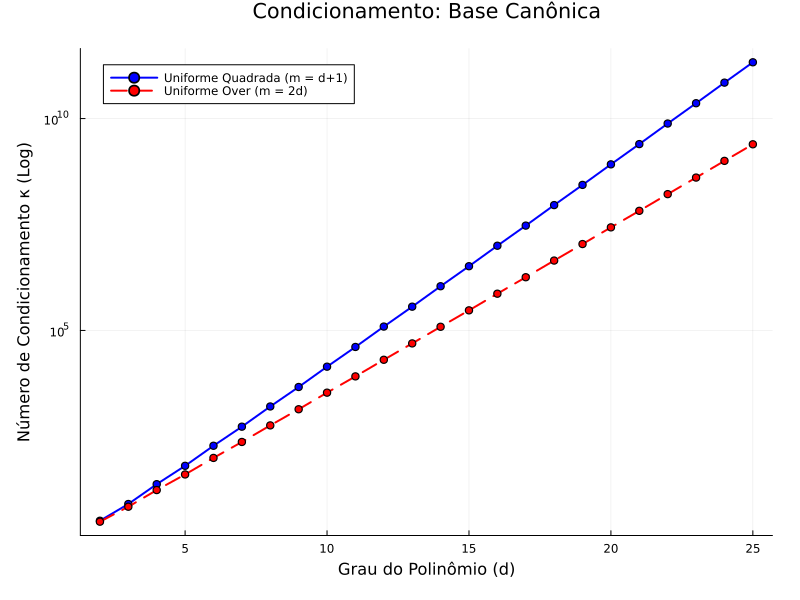

In [2]:
using Plots

function matrix_LX_canonical(X, d)
    m = length(X)
    V = zeros(Float64, m, d+1)
    for i in 1:m
        for j in 1:d+1
            V[i, j] = X[i]^(j-1)
        end
    end
    return V
end

function plot_conditioning_canonical(d_max=25)
    degrees = 2:d_max
    
    cond_uni_exact  = Float64[]
    cond_uni_over   = Float64[]
    
    for d in degrees
        push!(cond_uni_exact,  cond(matrix_LX_canonical(range(-1.0, 1.0, length=d+1), d)))
        m_over = 2 * d
        push!(cond_uni_over,   cond(matrix_LX_canonical(range(-1.0, 1.0, length=m_over), d)))
    end
    
    p = plot(title="Condicionamento: Base Canônica",
             xlabel="Grau do Polinômio (d)", 
             ylabel="Número de Condicionamento κ (Log)",
             yscale=:log10, 
             legend=:topleft,
             grid=true,
             size=(800, 600),
             margin=5Plots.mm)
             
    plot!(p, degrees, cond_uni_exact,  label="Uniforme Quadrada (m = d+1)", lw=2, marker=:circle, color=:blue)
    plot!(p, degrees, cond_uni_over,   label="Uniforme Over (m = 2d)", lw=2, ls=:dash, marker=:circle, color=:red)

    return p
end

plot_conditioning_canonical()

## Letra (e)

Calcule as matrizes de $L_X$ e $R_{X,d}$ usando a base dos polinômios interpoladores de Lagrange. Qual o condicionamento das matrizes $L_X$ e $R_{X,d}$ nestas bases?

As colunas das matrizes correspondem a aplicação das transformações nos vetores base. Isto é, $L_X = \begin{bmatrix} L_X^1 & L_X^2 & \cdots & L_X^{d+1}\end{bmatrix}$, onde
$$L_X^j = L_X(p_j) = \begin{bmatrix} p_j(x_1) \\ \vdots \\ p_j(x_{d+1}) \\ p_j(x_{d+2}) \\ \vdots \\ p_j(x_m) \end{bmatrix} = \begin{bmatrix} \delta_{1j} \\ \vdots \\ \delta_{(d+1)j} \\ p_j(x_{d+2}) \\ \vdots \\ p_j(x_m)\end{bmatrix}.$$

Logo, se $\ell = \left\{p_1,p_2,\dots,p_{d+1}\right\}$ é a base de dos polinômios interpoladores de Lagrange, temos que 
$$M_L := [L_X]_\ell = \begin{bmatrix} I_{d+1} \\ P\end{bmatrix},$$
onde $P$ é a matriz $(m- d - 1)\times (d+1)$ com as avaliações dos polinômios nos pontos "extras".

Como $R_{X,d}$ é a pseudo-inversa de $L_X$ (letra (c)), temos que a matriz $R_{X,d}$ na base de Lagrange é
$$T := [R_{X,d}]_\ell = (M_L^TM_L)^{-1}M_L^T.$$

Note que
$$M_L^TM = \begin{bmatrix} I_{d+1} & P^T\end{bmatrix}\begin{bmatrix} I_{d+1} \\ P\end{bmatrix} = I_{d+1} + P^TP.$$

Assim,
$$T = (I_{d+1} + P^TP)^{-1}\begin{bmatrix} I_{d+1} & P^T\end{bmatrix}.$$

Para analisar o condicionamento das matrizes nestas bases, basta observar o condicionamento de $M_L$, pois $\kappa(M_L) = \kappa(T)$ (letra (d)).

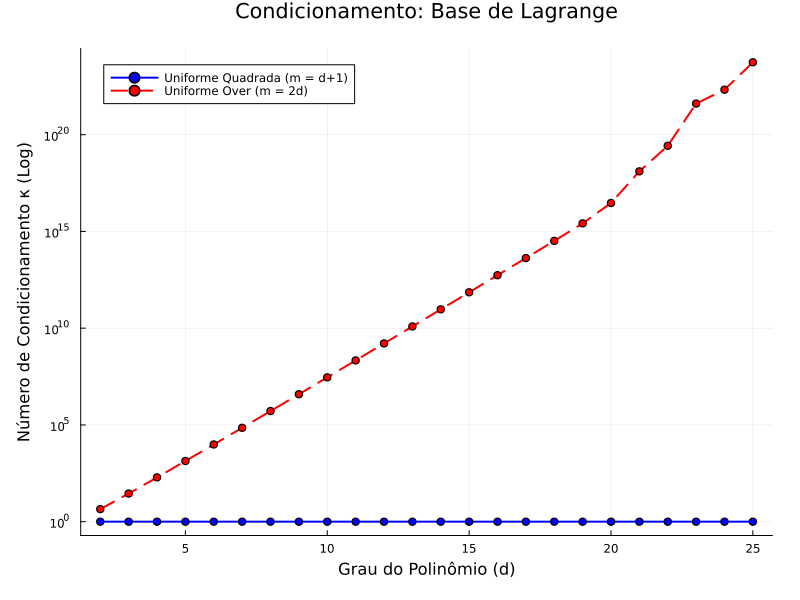

In [3]:
function denominator_lagrange(X, j, d)
    val = 1.0
    for k in 1:d+1
        if k != j
            val *= X[j] - X[k]
        end
    end
    return 1 / val
end

function lagrange_base_eval(X, x, j, d, D)
    val = D 
    for k in 1:d+1
        if k != j
            val *= (x - X[k])
        end
    end
    return val
end

function matrix_LX_lagrange(X, d)
    m = length(X)
    M_L = zeros(Float64, m, d + 1)
    
    for i in 1:(d + 1)
        M_L[i, i] = 1.0
    end

    if m == d + 1
        return M_L
    end

    X_base = @view X[1:d+1]

    for j in 1:(d + 1)
        D = denominator_lagrange(X_base, j, d)
        for i in (d+2):m
            M_L[i, j] = lagrange_base_eval(X_base, X[i], j, d, D)
        end
    end

    return M_L
end


function plot_conditioning(d_max=25)
    degrees = 2:d_max
    
    cond_uni_exact  = Float64[]
    cond_uni_over   = Float64[]
    
    for d in degrees
        push!(cond_uni_exact,  cond(matrix_LX_lagrange(range(-1.0, 1.0, length=d+1), d)))
        m_over = 2 * d
        push!(cond_uni_over,   cond(matrix_LX_lagrange(range(-1.0, 1.0, length=m_over), d)))
    end
    
    p = plot(title="Condicionamento: Base de Lagrange",
             xlabel="Grau do Polinômio (d)", 
             ylabel="Número de Condicionamento κ (Log)",
             yscale=:log10, 
             legend=:topleft,
             grid=true,
             size=(800, 600),
             margin=5Plots.mm)
             
    plot!(p, degrees, cond_uni_exact,  label="Uniforme Quadrada (m = d+1)", lw=2, marker=:circle, color=:blue)
    plot!(p, degrees, cond_uni_over,   label="Uniforme Over (m = 2d)", lw=2, ls=:dash, marker=:circle, color=:red)
    
    return p
end

plot_conditioning(25)



## Letra (f):

Compare a complexidade computacional de calcular $L_X$ e $R_{X,d}$ usando as bases canônica e de Lagrange com o condicionamento das matrizes.

### Complexidade na Base Canônica:


A complexidade para se calcular a matriz $V$ de $L_{X}$ é $O(md)$, pois, dado o conjunto $X = \left\{x_{1}, ..., x_{m}\right\}$
de pontos, calculamos as $m(d + 1)$ entradas da matriz, cada uma com custo $O(1)$ pois $V_{ij} = x_{i}^{j - 1}$ é
uma exponenciação de custo $O(1)$.


### Complexidade na Base de Lagrange:
O custo computacional para calcular a matriz de $L_{X}$ na base de lagrange é $O(d^{2}m)$. A $j$-ésima coluna da matriz $L$
de $L_{X}$ é $L_{X}(p_{j})$, $L_{X}$ aplicado no $j$-ésimo polinômio da base de lagrange. Como $p_{j}(x_{i}) = \delta_{ij}$ para
$1 \leq i \leq d + 1, 1 \leq j \leq d + 1$, então o bloco $(d + 1) \times (d + 1)$ superior de $L$ será a identidade. Se $m = d + 1$, então
$L$ é simplesmente a identidade (e $R_{X, d}$ também será!), um resultado muito bonito pois o condicionamento será 1,
o condicionamento perfeito. Porém, quando $m > d + 1$, teremos um bloco $(m - d - 1) \times (d + 1)$ de valores que a priore
não temos muitas informações. O que sabemos é que $L_{ij} = p_{j}(x_{i})$ para $m \geq i \geq d + 2$.

Para colocar as $d + 1$ entradas 1 na diagonal do bloco identidade, são necessárias $d + 1$ operações. Para calcular
as demais entradas, seguimos o seguinte algoritmo:
Analisamos coluna por coluna. O polinômio de lagrange é $$p_{j}(x) = \prod_{i \neq j}^{d + 1}\frac{x-x_{i}}{x_{j} - x_{i}}.$$
Vamos calcular apenas uma vez o denominador. São $d$ subtrações e $d - 1$ multiplicações. Ou seja, $2d - 1$ operações para
calcular o denominador. Para cada uma das $m - d - 1$ entradas da coluna, devemos calcular $\prod_{i \neq j}^{d + 1} x-x_{i}$
e depois dividir pelo denominador já calculado. No numerador fazemos $2d - 1$ operações, e com a divisão vamos para $2d$ operações. Logo, para cada coluna fazemos $(2d - 1) + (m - d - 1)(2d)$ operações. Como são $d + 1$ colunas, são necessárias
$$\left[(2d - 1) + (m - d - 1)(2d)\right](d + 1) = 2d^{2}m - 2d^{3} - d + 2dm - 2d^{2} - 1 \text{ operações.}$$
 Somado com as $d + 1$ da identidade
obtemos $2d^{2}m - 2d^{3} + 2dm - 2d^{2}$. 

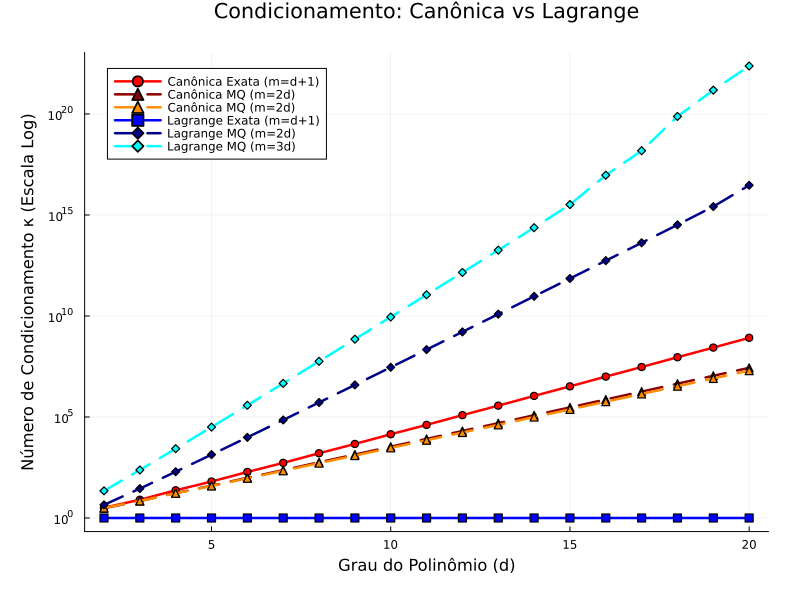

In [4]:
function plot_comparison_bases(d_max=20)
    degrees = 2:d_max
    
    cond_can_exato = Float64[]
    cond_can_2d   = Float64[]
    cond_can_3d = Float64[]

    cond_lag_exato = Float64[]
    cond_lag_2d    = Float64[]
    cond_lag_3d    = Float64[]
    
    for d in degrees
        X_exato = range(-1.0, 1.0, length=d+1)
        X_2d   = range(-1.0, 1.0, length=2d)
        X_3d   = range(-1.0, 1.0, length=3d)
        
        push!(cond_can_exato, cond(matrix_LX_canonical(X_exato, d)))
        push!(cond_can_2d,    cond(matrix_LX_canonical(X_2d, d)))
        push!(cond_can_3d,    cond(matrix_LX_canonical(X_3d, d)))       
        
        push!(cond_lag_exato, cond(matrix_LX_lagrange(X_exato, d)))
        push!(cond_lag_2d,    cond(matrix_LX_lagrange(X_2d, d)))
        push!(cond_lag_3d,    cond(matrix_LX_lagrange(X_3d, d)))

    end
    
    p = plot(title="Condicionamento: Canônica vs Lagrange",
             xlabel="Grau do Polinômio (d)",
             ylabel="Número de Condicionamento κ (Escala Log)",
             yscale=:log10, 
             legend=:topleft,
             grid=true,
             size=(800, 600),
             margin=6Plots.mm)
             
    plot!(p, degrees, cond_can_exato, label="Canônica Exata (m=d+1)", lw=2.5, color=:red, marker=:circle)
    plot!(p, degrees, cond_can_2d,    label="Canônica MQ (m=2d)", lw=2.5, color=:darkred, ls=:dash, marker=:utriangle)
    plot!(p, degrees, cond_can_3d,    label="Canônica MQ (m=2d)", lw=2.5, color=:darkorange, ls=:dash, marker=:utriangle)
    
    plot!(p, degrees, cond_lag_exato, label="Lagrange Exata (m=d+1)", lw=2.5, color=:blue, marker=:square)
    plot!(p, degrees, cond_lag_2d,    label="Lagrange MQ (m=2d)", lw=2.5, color=:darkblue, ls=:dash, marker=:diamond)
    plot!(p, degrees, cond_lag_3d,    label="Lagrange MQ (m=3d)", lw=2.5, color=:cyan, ls=:dash, marker=:diamond)
    
    return p
end

plot_comparison_bases(20)

Ou seja, quando $m = d+1$, utilizar a matriz na base de Lagrange é muito mais eficiente, pois precisamos de apenas $\approx d+1$ operações para construir a matriz identidade, e ela possui condicionamento 1, enquanto calcular $L_X$ na base canônica continua sendo $O(md)$ e o condicionamento cresce exponencialmente com $d$. Entretanto, percebe-se que quando $m > d+1$, o condicionamento da matriz de base Lagrange cresce mais rápido em função de $d$.